# Cross-set ticker universe

Equity tickers from **jacksoncrow** (NASDAQ stocks/ETFs → ~Apr 2020) and **jakewright** (9k+ full history → ~2024), plus Athena V1 coverage:

- **Athena daily FRED core** — `fred_api/fred_athena_core.parquet` (filtered allowlist from the macro catalog)
- **Athena equity/ETF targets** — SPY/QQQ/IWM/sectors etc. (Overview V1)

Goal: union of symbols, where each came from, gaps one set can fill for another, and whether Athena's filtered set is covered.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path(".").resolve()
JC = ROOT / "jacksoncrow_kaggle"
JW = ROOT / "jakewright_kaggle"
FRED = ROOT / "fred_api"

colors = {
    "both": "#4C78A8",
    "jacksoncrow": "#F58518",
    "jakewright": "#54A24B",
    "athena": "#E45756",
    "missing": "#B0B0B0",
}


def load_csv(p, **kw):
    return pd.read_csv(rf"\\?\{Path(p).resolve()}", **kw)

## Index jacksoncrow (per-file date spans)

In [2]:
jc_rows = []
for kind in ("stocks", "etfs"):
    for p in (JC / kind).glob("*.csv"):
        dates = load_csv(p, usecols=["Date"])["Date"]
        jc_rows.append(
            {
                "Ticker": p.stem,
                "Kind": kind,
                "rows": len(dates),
                "first": dates.min(),
                "last": dates.max(),
            }
        )

jc = pd.DataFrame(jc_rows)
jc["first"] = pd.to_datetime(jc["first"])
jc["last"] = pd.to_datetime(jc["last"])
print(f"jacksoncrow: {len(jc):,} tickers  {jc['rows'].sum():,} bars  {jc['first'].min().date()} → {jc['last'].max().date()}")
jc.head()

jacksoncrow: 8,049 tickers  28,151,758 bars  1962-01-02 → 2020-04-02


,Ticker,Kind,rows,first,last
0,A,stocks,5124,1999-11-18,2020-04-01
1,AA,stocks,14663,1962-01-02,2020-04-01
2,AACG,stocks,261,2019-03-11,2020-04-01
3,AAL,stocks,3653,2005-09-27,2020-04-01
4,AAMC,stocks,1837,2012-12-13,2020-04-01


## Index jakewright (parquet groupby)

In [3]:
jw_raw = pd.read_parquet(JW / "jakewright_kaggle_all_stock_data.parquet", columns=["Date", "Ticker"])
jw_raw["Date"] = pd.to_datetime(jw_raw["Date"])

jw = (
    jw_raw.groupby("Ticker", observed=True)["Date"]
    .agg(rows="size", first="min", last="max")
    .reset_index()
)
print(f"jakewright: {len(jw):,} tickers  {jw['rows'].sum():,} bars  {jw['first'].min().date()} → {jw['last'].max().date()}")
jw.head()


jakewright: 9,315 tickers  34,646,258 bars  1962-01-02 → 2024-11-04


,Ticker,rows,first,last
0,A,6280,1999-11-18,2024-11-04
1,AA,15819,1962-01-02,2024-11-04
2,AAAU,1566,2018-08-15,2024-11-04
3,AACG,4222,2008-01-29,2024-11-04
4,AACT,352,2023-06-13,2024-11-04


## Athena filtered sets

1. **FRED daily core** — curated allowlist written by `fred_api/explore_fred_api.ipynb` (rates/FX/equity_vol/commod).
2. **Equity/ETF targets** — Athena Overview V1 benchmarks (must exist in Markets OHLC, not only FRED mirrors).

In [4]:
athena = pd.read_parquet(FRED / "fred_athena_core.parquet")
print(f"athena FRED core: {len(athena)} series")
cols = [c for c in ["id", "label", "family", "obs_start", "obs_end", "span_years", "frequency"] if c in athena.columns]
display(athena[cols].sort_values("family" if "family" in cols else "id"))

# Overview V1 equity/ETF benchmarks (Markets OHLC symbols)
ATHENA_ETF = [
    "SPY", "QQQ", "IWM", "DIA",
    "XLK", "XLF", "XLE", "XLI", "XLV", "XLY", "XLP", "XLU", "XLB", "XLRE", "XLC",
    "TLT", "HYG", "LQD",
    "GLD", "SLV", "USO", "UNG",
    "VIXY",  # tradeable VIX proxy; spot VIX is FRED VIXCLS
]

# a few FRED core ids → closest equity/ETF analogues (coverage check only)
FRED_TO_TICKER = {
    "SP500": "SPY",
    "NASDAQCOM": "QQQ",
    "VIXCLS": "VIXY",
    "DCOILWTICO": "USO",
    "DHHNGSP": "UNG",
}

athena_etf = pd.DataFrame({"Ticker": ATHENA_ETF})
athena_etf["jacksoncrow"] = athena_etf["Ticker"].isin(set(jc["Ticker"]))
athena_etf["jakewright"] = athena_etf["Ticker"].isin(set(jw["Ticker"]))
athena_etf["source"] = athena_etf.apply(
    lambda r: (
        "both" if r["jacksoncrow"] and r["jakewright"]
        else "jacksoncrow" if r["jacksoncrow"]
        else "jakewright" if r["jakewright"]
        else "missing"
    ),
    axis=1,
)

print("\nAthena equity/ETF target coverage:")
print(athena_etf["source"].value_counts().to_string())
display(athena_etf)

fred_cov = athena[["id"] + [c for c in ["label", "family"] if c in athena.columns]].copy()
fred_cov["ticker_analogue"] = fred_cov["id"].map(FRED_TO_TICKER)
fred_cov["analogue_in_jc"] = fred_cov["ticker_analogue"].isin(set(jc["Ticker"]))
fred_cov["analogue_in_jw"] = fred_cov["ticker_analogue"].isin(set(jw["Ticker"]))
print("\nFRED core rows with equity/ETF analogues:")
display(fred_cov.dropna(subset=["ticker_analogue"]))


athena FRED core: 30 series


,id,label,family,obs_start,obs_end,span_years,frequency
22,DCOILWTICO,WTI crude,commod,1986-01-02,2026-08-18,40.624230,D
23,DCOILBRENTEU,Brent crude,commod,1987-05-20,2026-08-18,39.247091,D
24,DHHNGSP,Henry Hub nat gas,commod,1997-01-07,2026-08-18,29.609856,D
25,DHOILNYH,NYH heating oil,commod,1986-06-02,2026-08-18,40.210815,D
26,DJFUELUSGULF,Gulf Coast jet fuel,commod,1990-04-02,2026-08-18,36.377823,D
27,DPROPANEMBTX,Mont Belvieu propane,commod,1992-07-09,2026-08-18,34.108145,D
28,OVXCLS,Oil ETF vol (OVX),commod,2007-05-10,2026-08-20,19.279945,D
29,GVZCLS,Gold ETF vol (GVZ),commod,2008-06-03,2026-08-20,18.212183,D
19,SP500,S&P 500,equity_vol,2016-08-22,2026-08-21,9.995893,D
20,VIXCLS,VIX,equity_vol,1990-01-02,2026-08-20,36.629706,D



Athena equity/ETF target coverage:
source
jacksoncrow    15
both            8


,Ticker,jacksoncrow,jakewright,source
0,SPY,True,True,both
1,QQQ,True,True,both
2,IWM,True,False,jacksoncrow
3,DIA,True,True,both
4,XLK,True,False,jacksoncrow
5,XLF,True,False,jacksoncrow
6,XLE,True,False,jacksoncrow
7,XLI,True,False,jacksoncrow
8,XLV,True,False,jacksoncrow
9,XLY,True,False,jacksoncrow



FRED core rows with equity/ETF analogues:


,id,label,family,ticker_analogue,analogue_in_jc,analogue_in_jw
19,SP500,S&P 500,equity_vol,SPY,True,True
20,VIXCLS,VIX,equity_vol,VIXY,True,True
21,NASDAQCOM,Nasdaq Composite,equity_vol,QQQ,True,True
22,DCOILWTICO,WTI crude,commod,USO,True,True
24,DHHNGSP,Henry Hub nat gas,commod,UNG,True,True


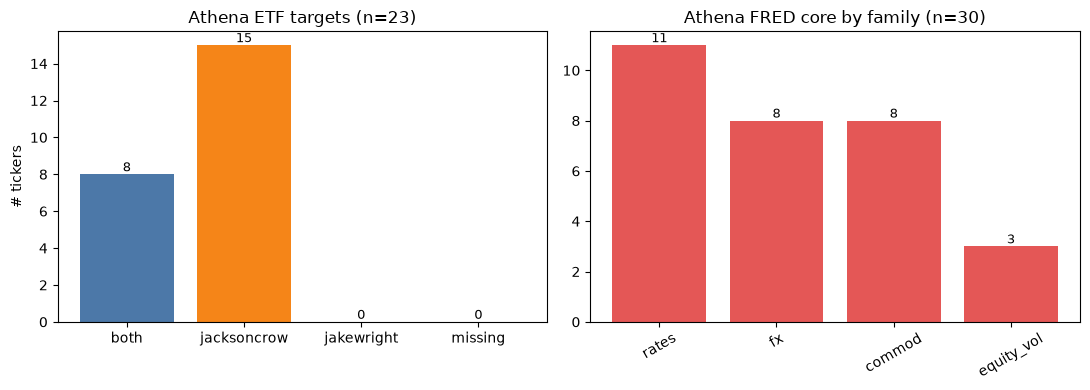

Athena ETF targets missing from both Kaggle sets: none


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

etf_counts = athena_etf["source"].value_counts().reindex(
    ["both", "jacksoncrow", "jakewright", "missing"], fill_value=0
)
axes[0].bar(
    etf_counts.index,
    etf_counts.values,
    color=[colors.get(k, colors["missing"]) for k in etf_counts.index],
)
axes[0].set_title(f"Athena ETF targets (n={len(athena_etf)})")
axes[0].set_ylabel("# tickers")
for i, v in enumerate(etf_counts.values):
    axes[0].text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)

fam = athena["family"].value_counts()
axes[1].bar(fam.index.astype(str), fam.values, color=colors["athena"])
axes[1].set_title(f"Athena FRED core by family (n={len(athena)})")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(fam.values):
    axes[1].text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

missing_etf = athena_etf.loc[athena_etf["source"] == "missing", "Ticker"].tolist()
print(f"Athena ETF targets missing from both Kaggle sets: {missing_etf or 'none'}")


## Price coverage by start year (full jakewright set)

All jakewright series Close histories. Stats first, then one plot with every series colored by the decade it begins (month-end for plot speed).

series with prices: 9,315
date range: 1962-01-02 → 2024-11-04
bars total: 34,646,258

start-decade clusters:
                 n     bars  median_span_yrs
start_decade                                
1960            31   489191        62.839151
1970           169  2182163        51.701574
1980           684  7125336        42.061602
1990          1215  8871371        28.966461
2000          1538  7479896        18.985626
2010          2764  6560107         9.399042
2020          2914  1938194         2.995209

per-series coverage (oldest 15 / newest 15):


,Ticker,rows,first,last,span_years,start_decade
837,BA,15819,1962-01-02,2024-11-04,62.839151,1960
3147,FL,15819,1962-01-02,2024-11-04,62.839151,1960
5465,MO,15819,1962-01-02,2024-11-04,62.839151,1960
1257,BP,15819,1962-01-02,2024-11-04,62.839151,1960
4787,KR,15819,1962-01-02,2024-11-04,62.839151,1960
5531,MRO,15819,1962-01-02,2024-11-04,62.839151,1960
4208,IBM,15819,1962-01-02,2024-11-04,62.839151,1960
1924,CNP,15819,1962-01-02,2024-11-04,62.839151,1960
5523,MRK,15819,1962-01-02,2024-11-04,62.839151,1960
2622,ED,15819,1962-01-02,2024-11-04,62.839151,1960


,Ticker,rows,first,last,span_years,start_decade
3015,FBLA,9,2024-10-23,2024-11-04,0.032854,2020
3101,FGL,9,2024-10-23,2024-11-04,0.032854,2020
4868,LBGJ,8,2024-10-23,2024-11-01,0.024641,2020
1489,CAPN,7,2024-10-24,2024-11-01,0.021903,2020
6712,PRB,1,2024-10-24,2024-10-24,0.000000,2020
4358,INGM,8,2024-10-24,2024-11-04,0.030116,2020
2047,CRCQW,1,2024-10-24,2024-10-24,0.000000,2020
7473,SEPN,7,2024-10-25,2024-11-04,0.027379,2020
6676,POLE,5,2024-10-28,2024-11-01,0.010951,2020
8687,VCIC,5,2024-10-28,2024-11-01,0.010951,2020


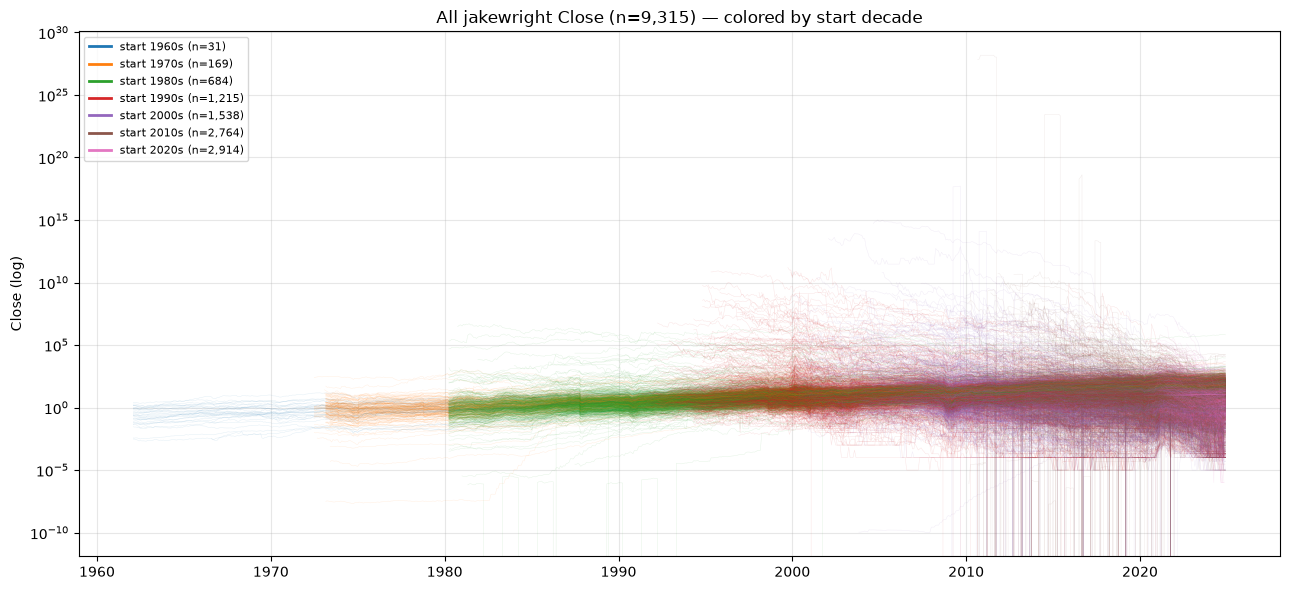

In [6]:
cov = jw.copy()
cov["span_years"] = (cov["last"] - cov["first"]).dt.days / 365.25
cov["start_decade"] = (cov["first"].dt.year // 10) * 10
cov = cov.sort_values("first")

print(f"series with prices: {len(cov):,}")
print(f"date range: {cov['first'].min().date()} → {cov['last'].max().date()}")
print(f"bars total: {cov['rows'].sum():,}")
print("\nstart-decade clusters:")
print(
    cov.groupby("start_decade")
    .agg(n=("Ticker", "size"), bars=("rows", "sum"), median_span_yrs=("span_years", "median"))
    .to_string()
)
print("\nper-series coverage (oldest 15 / newest 15):")
display(cov[["Ticker", "rows", "first", "last", "span_years", "start_decade"]].head(15))
display(cov[["Ticker", "rows", "first", "last", "span_years", "start_decade"]].tail(15))

prices = pd.read_parquet(
    JW / "jakewright_kaggle_all_stock_data.parquet",
    columns=["Date", "Ticker", "Close"],
)
prices["Date"] = pd.to_datetime(prices["Date"])
# month-end downsample so ~9k lines stay plottable
month = (
    prices.set_index("Date")
    .groupby("Ticker", observed=True)["Close"]
    .resample("ME")
    .last()
    .dropna()
    .reset_index()
)
month["start_decade"] = month["Ticker"].map(cov.set_index("Ticker")["start_decade"])

decades = sorted(cov["start_decade"].unique())
cmap = plt.cm.tab10
decade_color = {d: cmap(i % 10) for i, d in enumerate(decades)}

fig, ax = plt.subplots(figsize=(13, 6))
for t, g in month.groupby("Ticker", observed=True):
    d = int(g["start_decade"].iloc[0])
    ax.plot(g["Date"], g["Close"], lw=0.35, alpha=0.12, color=decade_color[d])

for d in decades:
    ax.plot([], [], color=decade_color[d], lw=2, label=f"start {d}s (n={(cov['start_decade']==d).sum():,})")
ax.legend(loc="upper left", fontsize=8)
ax.set_yscale("log")
ax.set_title(f"All jakewright Close (n={len(cov):,}) — colored by start decade")
ax.set_ylabel("Close (log)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Universe membership

In [7]:
jc_set = set(jc["Ticker"])
jw_set = set(jw["Ticker"])

universe = sorted(jc_set | jw_set)
memb = pd.DataFrame({"Ticker": universe})
memb["jacksoncrow"] = memb["Ticker"].isin(jc_set)
memb["jakewright"] = memb["Ticker"].isin(jw_set)
memb["source"] = memb.apply(
    lambda r: "both" if r["jacksoncrow"] and r["jakewright"] else ("jacksoncrow" if r["jacksoncrow"] else "jakewright"),
    axis=1,
)

counts = memb["source"].value_counts()
print(f"universe: {len(memb):,} unique tickers")
print(counts.to_string())
display(memb.head(10))

memb["athena_etf"] = memb["Ticker"].isin(set(ATHENA_ETF))
print(f"universe tickers that are Athena ETF targets: {memb['athena_etf'].sum()}")


universe: 13,253 unique tickers
source
jakewright     5204
both           4111
jacksoncrow    3938


,Ticker,jacksoncrow,jakewright,source
0,A,True,True,both
1,AA,True,True,both
2,AAAU,True,True,both
3,AACG,True,True,both
4,AACT,False,True,jakewright
5,AACT-UN,False,True,jakewright
6,AADI,False,True,jakewright
7,AADR,True,False,jacksoncrow
8,AAGH,False,True,jakewright
9,AAGR,False,True,jakewright


universe tickers that are Athena ETF targets: 23


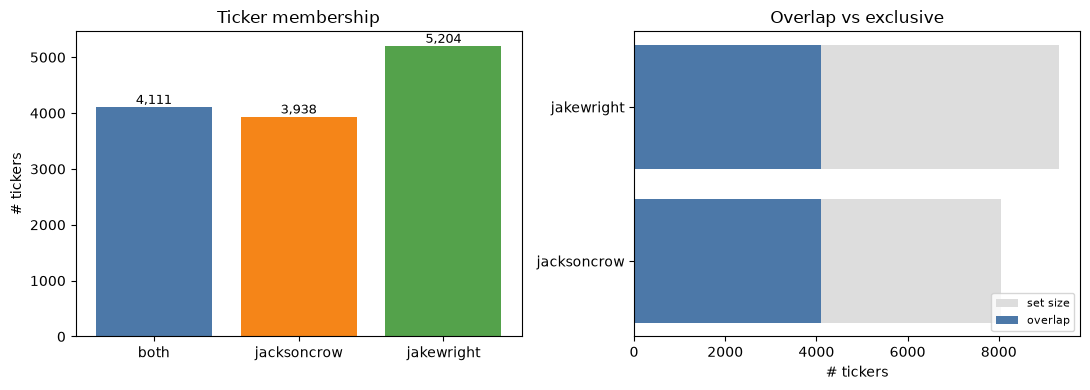

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

order = ["both", "jacksoncrow", "jakewright"]
colors = {"both": "#4C78A8", "jacksoncrow": "#F58518", "jakewright": "#54A24B"}
vals = [counts.get(k, 0) for k in order]
axes[0].bar(order, vals, color=[colors[k] for k in order])
axes[0].set_title("Ticker membership")
axes[0].set_ylabel("# tickers")
for i, v in enumerate(vals):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

# simple 2-set overlap diagram via stacked horizontal bars
only_jc = counts.get("jacksoncrow", 0)
both = counts.get("both", 0)
only_jw = counts.get("jakewright", 0)
axes[1].barh(["jacksoncrow", "jakewright"], [only_jc + both, only_jw + both], color="#ddd", label="set size")
axes[1].barh(["jacksoncrow", "jakewright"], [both, both], color=colors["both"], label="overlap")
axes[1].set_xlabel("# tickers")
axes[1].set_title("Overlap vs exclusive")
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## Ticker gaps (one set fills the other's missing symbols)

In [9]:
only_jc_tickers = memb.loc[memb["source"] == "jacksoncrow", "Ticker"]
only_jw_tickers = memb.loc[memb["source"] == "jakewright", "Ticker"]

print(f"jakewright can add {len(only_jw_tickers):,} tickers jacksoncrow lacks")
print(f"jacksoncrow can add {len(only_jc_tickers):,} tickers jakewright lacks")

jc_only = jc[jc["Ticker"].isin(only_jc_tickers)].sort_values("rows", ascending=False)
jw_only = jw[jw["Ticker"].isin(only_jw_tickers)].sort_values("rows", ascending=False)

print("\njacksoncrow-only (top by bars):")
display(jc_only.head(15))
print("jakewright-only (top by bars):")
display(jw_only.head(15))

jakewright can add 5,204 tickers jacksoncrow lacks
jacksoncrow can add 3,938 tickers jakewright lacks

jacksoncrow-only (top by bars):


,Ticker,Kind,rows,first,last
390,ARNC,stocks,14663,1962-01-02,2020-04-01
3603,NAV,stocks,14663,1962-01-02,2020-04-01
5488,UTX,stocks,12676,1970-01-02,2020-04-01
5487,UTX#,stocks,12676,1970-01-02,2020-04-01
2561,HRC,stocks,12064,1972-06-01,2020-04-01
709,BLL,stocks,11885,1973-02-21,2020-04-01
4703,SCX,stocks,11885,1973-02-21,2020-04-01
2858,JCP,stocks,11885,1973-02-21,2020-04-01
2702,IIN,stocks,11885,1973-02-21,2020-04-01
4246,PNM,stocks,11884,1973-02-21,2020-04-01


jakewright-only (top by bars):


,Ticker,rows,first,last
7268,RTX,15756,1962-04-02,2024-11-04
9034,WLY,13160,1972-06-02,2024-11-04
7284,RVTY,13040,1973-02-21,2024-11-04
7782,SONY,13040,1973-02-21,2024-11-04
864,BALL,13040,1973-02-21,2024-11-04
8477,TXNM,13040,1973-02-21,2024-11-04
1005,BF-A,12990,1973-05-03,2024-11-04
2138,CTA-PB,12843,1973-02-21,2024-11-04
1877,CMS-PB,12529,1973-02-21,2024-11-01
8482,TY-P,12460,1973-02-21,2024-11-01


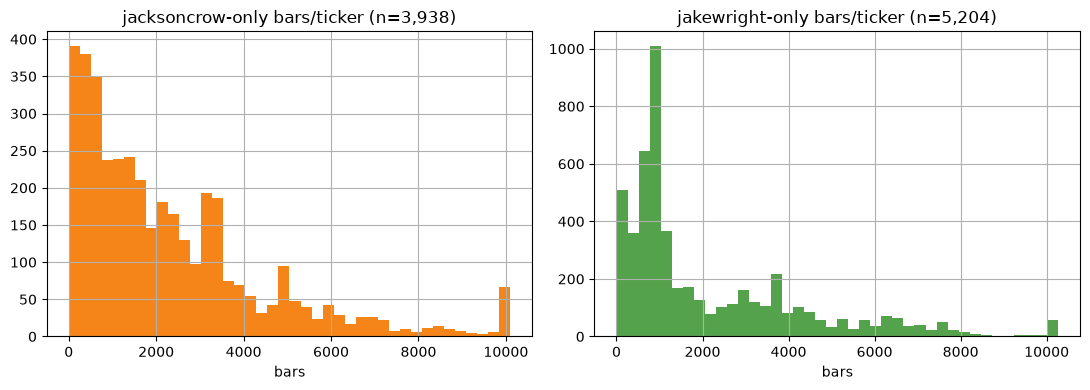

,n
Kind,
etfs,2092
stocks,1846


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

jc_only["rows"].clip(upper=jc_only["rows"].quantile(0.99)).hist(bins=40, ax=axes[0], color=colors["jacksoncrow"])
axes[0].set_title(f"jacksoncrow-only bars/ticker (n={len(jc_only):,})")
axes[0].set_xlabel("bars")

jw_only["rows"].clip(upper=jw_only["rows"].quantile(0.99)).hist(bins=40, ax=axes[1], color=colors["jakewright"])
axes[1].set_title(f"jakewright-only bars/ticker (n={len(jw_only):,})")
axes[1].set_xlabel("bars")

plt.tight_layout()
plt.show()

if "Kind" in jc_only.columns:
    display(jc_only.groupby("Kind").size().rename("n").to_frame())

## Date-range gaps on shared tickers

For tickers in **both**, compare first/last dates — who can extend the other's history.

In [11]:
shared = memb.loc[memb["source"] == "both", ["Ticker"]].copy()
cmp = (
    shared
    .merge(jc[["Ticker", "first", "last", "rows"]].add_suffix("_jc").rename(columns={"Ticker_jc": "Ticker"}), on="Ticker")
    .merge(jw[["Ticker", "first", "last", "rows"]].add_suffix("_jw").rename(columns={"Ticker_jw": "Ticker"}), on="Ticker")
)

cmp["jw_extends_end"] = (cmp["last_jw"] - cmp["last_jc"]).dt.days
cmp["jc_extends_end"] = (cmp["last_jc"] - cmp["last_jw"]).dt.days
cmp["jw_extends_start"] = (cmp["first_jc"] - cmp["first_jw"]).dt.days  # >0 → jw starts earlier
cmp["jc_extends_start"] = (cmp["first_jw"] - cmp["first_jc"]).dt.days  # >0 → jc starts earlier

print(f"shared tickers: {len(cmp):,}")
print(f"jakewright lasts later than jacksoncrow: {(cmp['jw_extends_end'] > 0).sum():,}  median extra days={cmp.loc[cmp['jw_extends_end'] > 0, 'jw_extends_end'].median():.0f}")
print(f"jacksoncrow lasts later than jakewright: {(cmp['jc_extends_end'] > 0).sum():,}")
print(f"jakewright starts earlier: {(cmp['jw_extends_start'] > 0).sum():,}")
print(f"jacksoncrow starts earlier: {(cmp['jc_extends_start'] > 0).sum():,}")
cmp.head()

shared tickers: 4,111
jakewright lasts later than jacksoncrow: 4,111  median extra days=1678
jacksoncrow lasts later than jakewright: 0
jakewright starts earlier: 88
jacksoncrow starts earlier: 318


,Ticker,first_jc,last_jc,rows_jc,first_jw,last_jw,rows_jw,jw_extends_end,jc_extends_end,jw_extends_start,jc_extends_start
0,A,1999-11-18,2020-04-01,5124,1999-11-18,2024-11-04,6280,1678,-1678,0,0
1,AA,1962-01-02,2020-04-01,14663,1962-01-02,2024-11-04,15819,1678,-1678,0,0
2,AAAU,2018-08-15,2020-04-01,410,2018-08-15,2024-11-04,1566,1678,-1678,0,0
3,AACG,2019-03-11,2020-04-01,261,2008-01-29,2024-11-04,4222,1678,-1678,4059,-4059
4,AAL,2005-09-27,2020-04-01,3653,2005-09-27,2024-11-04,4809,1678,-1678,0,0


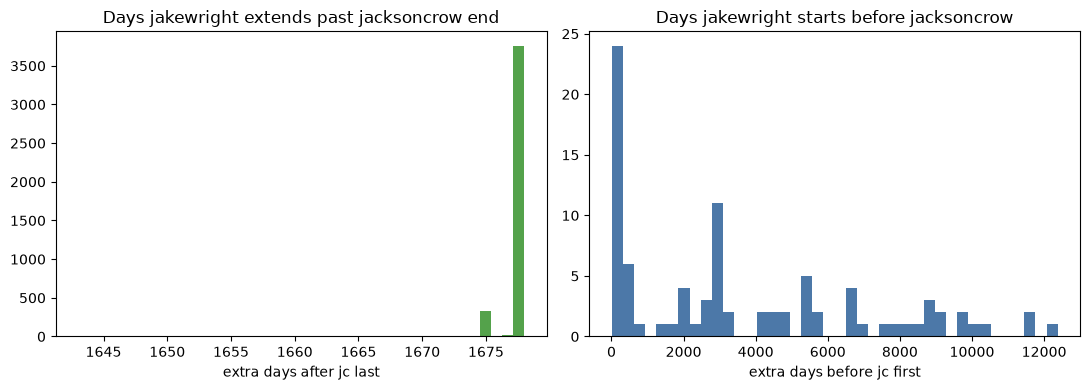

biggest end-date fills (jakewright after jacksoncrow cutoff):


,Ticker,last_jc,last_jw,jw_extends_end,rows_jc,rows_jw
0,A,2020-04-01,2024-11-04,1678,5124,6280
1,AA,2020-04-01,2024-11-04,1678,14663,15819
2,AAAU,2020-04-01,2024-11-04,1678,410,1566
3,AACG,2020-04-01,2024-11-04,1678,261,4222
4,AAL,2020-04-01,2024-11-04,1678,3653,4809
5,AAME,2020-04-01,2024-11-04,1678,10098,11254
6,AAOI,2020-04-01,2024-11-04,1678,1640,2796
7,AAON,2020-04-01,2024-11-04,1678,6873,8029
8,AAP,2020-04-01,2024-11-04,1678,4616,5772
9,AAPL,2020-04-01,2024-11-04,1678,9909,11066


biggest start-date fills (jakewright earlier history):


,Ticker,first_jc,first_jw,jw_extends_start,rows_jc,rows_jw
3079,RAMP,2017-11-02,1983-12-14,12377,272,10306
3609,THMO,2019-03-11,1987-06-05,11602,269,9428
625,CADE,2017-04-24,1985-10-16,11513,741,9842
1091,DOC,2013-07-19,1985-05-23,10284,1688,9942
3228,SAFE,2017-06-22,1989-11-16,10080,699,8808
1408,FI,2013-08-09,1986-09-25,9815,1673,9604
940,CTRA,2016-08-18,1990-02-08,9688,911,8751
1637,GNSS,2019-03-11,1994-04-04,9107,269,7702
2122,KRMD,2019-03-11,1994-04-05,9106,269,7701
1855,IBCP,2010-02-02,1985-09-04,8917,2559,9871


where jacksoncrow starts earlier:


,Ticker,first_jc,first_jw,jc_extends_start,rows_jc,rows_jw
1702,GV,1974-04-09,2022-05-17,17570,11589,621
950,CUB,1980-03-17,2024-08-12,16219,10098,59
887,CR,1980-03-17,2023-03-29,15717,10098,404
2159,LB,1982-04-01,2024-06-28,15429,9583,90
1014,DBD,1981-12-31,2023-08-14,15201,9645,310
3833,VAL,1980-02-28,2021-05-03,15040,10110,884
634,CAMP,1983-12-13,2024-10-11,14913,9151,17
378,BAM,1983-12-30,2022-12-01,14216,9141,484
1971,IR,1980-03-17,2017-05-12,13570,10098,1883
2403,MNR,1987-10-01,2023-10-25,13173,8191,259


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

extra_end = cmp.loc[cmp["jw_extends_end"] > 0, "jw_extends_end"]
axes[0].hist(extra_end, bins=40, color=colors["jakewright"])
axes[0].set_title("Days jakewright extends past jacksoncrow end")
axes[0].set_xlabel("extra days after jc last")

extra_start = cmp.loc[cmp["jw_extends_start"] > 0, "jw_extends_start"]
axes[1].hist(extra_start, bins=40, color=colors["both"])
axes[1].set_title("Days jakewright starts before jacksoncrow")
axes[1].set_xlabel("extra days before jc first")

plt.tight_layout()
plt.show()

print("biggest end-date fills (jakewright after jacksoncrow cutoff):")
display(cmp.nlargest(10, "jw_extends_end")[["Ticker", "last_jc", "last_jw", "jw_extends_end", "rows_jc", "rows_jw"]])
print("biggest start-date fills (jakewright earlier history):")
display(cmp.nlargest(10, "jw_extends_start")[["Ticker", "first_jc", "first_jw", "jw_extends_start", "rows_jc", "rows_jw"]])
print("where jacksoncrow starts earlier:")
display(cmp.nlargest(10, "jc_extends_start")[["Ticker", "first_jc", "first_jw", "jc_extends_start", "rows_jc", "rows_jw"]])

## Active-ticker timeline (who covers which years)

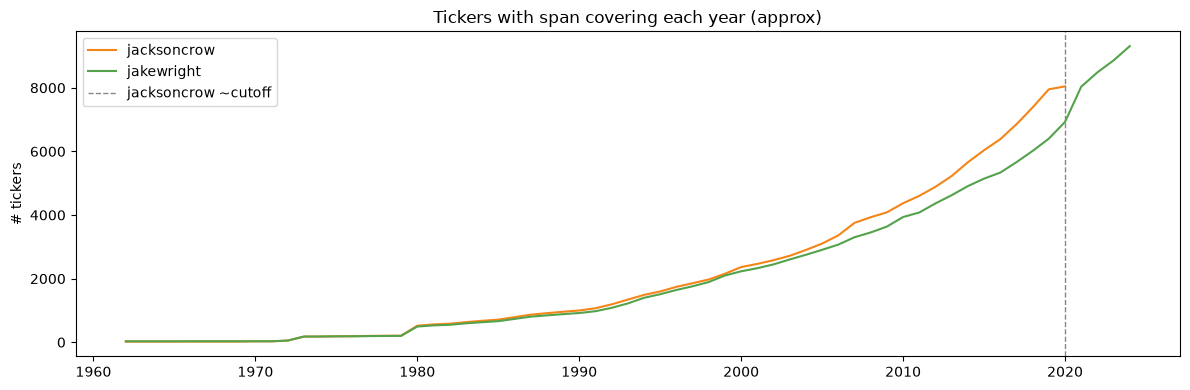

post-2020: jakewright alone covers years jacksoncrow cannot


,jacksoncrow,jakewright
2018,7383.0,6016
2019,7953.0,6401
2020,8045.0,6928
2021,NaN,8034
2022,NaN,8486
2023,NaN,8863
2024,NaN,9311


In [13]:
# approximate active years from first/last span (not exact bar presence)
def year_counts(df, first_col="first", last_col="last"):
    years = range(int(df[first_col].dt.year.min()), int(df[last_col].dt.year.max()) + 1)
    out = {}
    for y in years:
        out[y] = ((df[first_col].dt.year <= y) & (df[last_col].dt.year >= y)).sum()
    return pd.Series(out, name="n_tickers")

jc_years = year_counts(jc)
jw_years = year_counts(jw)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(jc_years.index, jc_years.values, label="jacksoncrow", color=colors["jacksoncrow"])
ax.plot(jw_years.index, jw_years.values, label="jakewright", color=colors["jakewright"])
ax.axvline(2020, color="#888", ls="--", lw=1, label="jacksoncrow ~cutoff")
ax.set_title("Tickers with span covering each year (approx)")
ax.set_ylabel("# tickers")
ax.legend()
plt.tight_layout()
plt.show()

print("post-2020: jakewright alone covers years jacksoncrow cannot")
display(pd.DataFrame({"jacksoncrow": jc_years, "jakewright": jw_years}).loc[2018:])

## Summary table

In [14]:
start_col = next((c for c in ["obs_start", "observation_start"] if c in athena.columns), None)
end_col = next((c for c in ["obs_end", "observation_end"] if c in athena.columns), None)

summary = pd.DataFrame(
    [
        {
            "set": "jacksoncrow",
            "tickers": len(jc),
            "bars": int(jc["rows"].sum()),
            "first": jc["first"].min().date(),
            "last": jc["last"].max().date(),
            "exclusive": int(counts.get("jacksoncrow", 0)),
        },
        {
            "set": "jakewright",
            "tickers": len(jw),
            "bars": int(jw["rows"].sum()),
            "first": jw["first"].min().date(),
            "last": jw["last"].max().date(),
            "exclusive": int(counts.get("jakewright", 0)),
        },
        {
            "set": "athena_fred_core",
            "tickers": len(athena),
            "bars": None,
            "first": pd.to_datetime(athena[start_col]).min().date() if start_col else None,
            "last": pd.to_datetime(athena[end_col]).max().date() if end_col else None,
            "exclusive": None,
        },
        {
            "set": "athena_etf_targets",
            "tickers": len(athena_etf),
            "bars": None,
            "first": None,
            "last": None,
            "exclusive": int((athena_etf["source"] == "missing").sum()),
        },
        {
            "set": "union_equity",
            "tickers": len(memb),
            "bars": None,
            "first": min(jc["first"].min(), jw["first"].min()).date(),
            "last": max(jc["last"].max(), jw["last"].max()).date(),
            "exclusive": None,
        },
    ]
)
display(summary)
print(f"equity overlap (both): {counts.get('both', 0):,}")
print(f"athena ETF covered by >=1 kaggle set: {(athena_etf['source'] != 'missing').sum()}/{len(athena_etf)}")
print(f"athena FRED core series: {len(athena)} (all from FRED, not equity tickers)")

universe_df = memb.copy()


,set,tickers,bars,first,last,exclusive
0,jacksoncrow,8049,28151758.0,1962-01-02,2020-04-02,3938.0
1,jakewright,9315,34646258.0,1962-01-02,2024-11-04,5204.0
2,athena_fred_core,30,NaN,1954-07-01,2026-08-21,NaN
3,athena_etf_targets,23,NaN,None,None,0.0
4,union_equity,13253,NaN,1962-01-02,2024-11-04,NaN


equity overlap (both): 4,111
athena ETF covered by >=1 kaggle set: 23/23
athena FRED core series: 30 (all from FRED, not equity tickers)


## Gap consolidation (shared tickers)

For tickers in **both** sets: stitch Close with jakewright preferred, jacksoncrow filling missing dates (`combine_first`). Stats on what got filled, then plot the consolidated lines (month-end, colored by start decade).

shared tickers stitched: 4,111
tickers with jc gap-fill: 467
total dates filled from jacksoncrow: 598,009
stitched bars total: 23,979,145


,Ticker,jw_bars,jc_bars,stitched_bars,filled_from_jc,first,last,start_decade
1702,GV,621,11589,12210,11589,1974-04-09,2024-11-04,1970
3833,VAL,884,10110,10994,10110,1980-02-28,2024-11-04,1980
950,CUB,59,10098,10157,10098,1980-03-17,2024-11-01,1980
887,CR,404,10098,10502,10098,1980-03-17,2024-11-04,1980
1014,DBD,310,9645,9955,9645,1981-12-31,2024-11-04,1980
2159,LB,90,9583,9673,9583,1982-04-01,2024-11-04,1980
1971,IR,1883,10098,11254,9371,1980-03-17,2024-11-04,1980
634,CAMP,17,9151,9168,9151,1983-12-13,2024-11-04,1980
378,BAM,484,9141,9625,9141,1983-12-30,2024-11-04,1980
2544,NE,858,8702,9560,8702,1985-09-23,2024-11-04,1980


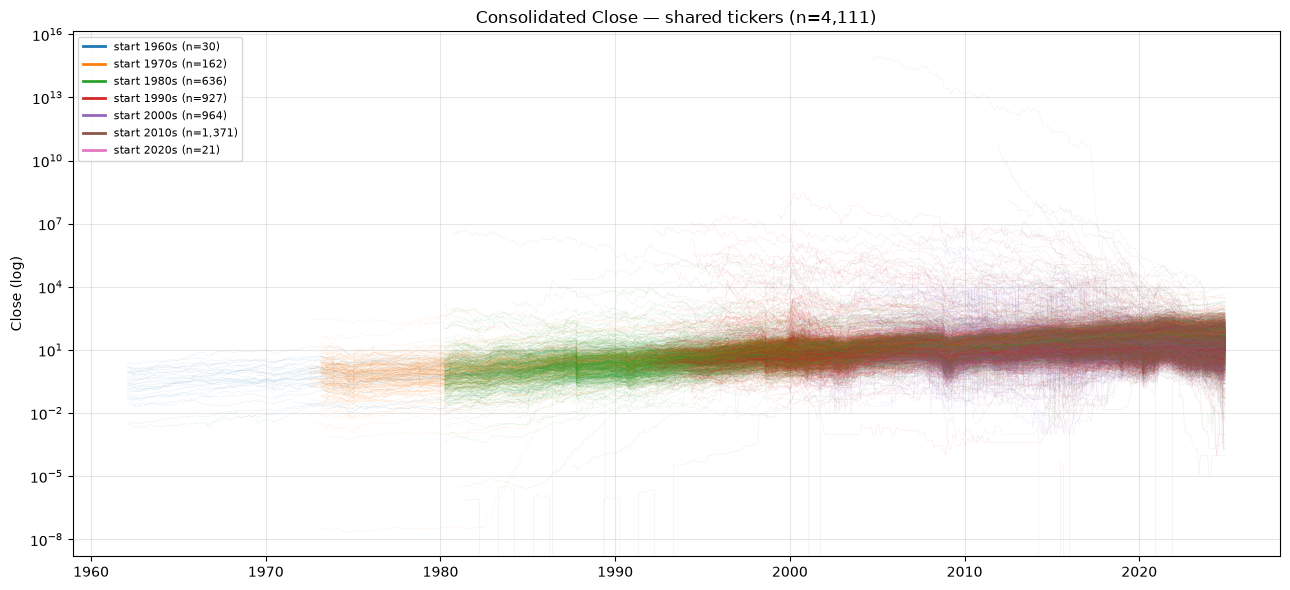

In [15]:
shared_tickers = memb.loc[memb["source"] == "both", "Ticker"].tolist()
jc_kind = jc.set_index("Ticker")["Kind"]

jw_px = pd.read_parquet(
    JW / "jakewright_kaggle_all_stock_data.parquet",
    columns=["Date", "Ticker", "Close"],
)
jw_px = jw_px[jw_px["Ticker"].isin(shared_tickers)].copy()
jw_px["Date"] = pd.to_datetime(jw_px["Date"])
jw_grp = {t: g.set_index("Date")["Close"].sort_index() for t, g in jw_px.groupby("Ticker", observed=True)}

fill_rows = []
month_rows = []
for t in shared_tickers:
    j = jw_grp[t]
    j = j[~j.index.duplicated(keep="last")]
    c = load_csv(JC / jc_kind.loc[t] / f"{t}.csv", usecols=["Date", "Close"], parse_dates=["Date"])
    c = c.set_index("Date")["Close"].sort_index()
    c = c[~c.index.duplicated(keep="last")]

    stitched = j.combine_first(c)  # jw preferred; jc fills holes / earlier dates
    n_filled = int((~stitched.index.isin(j.index)).sum())
    fill_rows.append(
        {
            "Ticker": t,
            "jw_bars": len(j),
            "jc_bars": len(c),
            "stitched_bars": len(stitched),
            "filled_from_jc": n_filled,
            "first": stitched.index.min(),
            "last": stitched.index.max(),
        }
    )
    m = stitched.resample("ME").last().dropna()
    month_rows.append(pd.DataFrame({"Date": m.index, "Ticker": t, "Close": m.to_numpy()}))

fill_df = pd.DataFrame(fill_rows).sort_values("filled_from_jc", ascending=False)
fill_df["start_decade"] = (pd.to_datetime(fill_df["first"]).dt.year // 10) * 10

print(f"shared tickers stitched: {len(fill_df):,}")
print(f"tickers with jc gap-fill: {(fill_df['filled_from_jc'] > 0).sum():,}")
print(f"total dates filled from jacksoncrow: {fill_df['filled_from_jc'].sum():,}")
print(f"stitched bars total: {fill_df['stitched_bars'].sum():,}")
display(fill_df.head(20))

month = pd.concat(month_rows, ignore_index=True)
month = month.merge(fill_df[["Ticker", "start_decade"]], on="Ticker")

decades = sorted(fill_df["start_decade"].unique())
cmap = plt.cm.tab10
decade_color = {int(d): cmap(i % 10) for i, d in enumerate(decades)}

fig, ax = plt.subplots(figsize=(13, 6))
for t, g in month.groupby("Ticker", observed=True):
    d = int(g["start_decade"].iloc[0])
    ax.plot(g["Date"], g["Close"], lw=0.35, alpha=0.12, color=decade_color[d])

for d in decades:
    ax.plot([], [], color=decade_color[int(d)], lw=2, label=f"start {int(d)}s (n={(fill_df['start_decade']==d).sum():,})")
ax.legend(loc="upper left", fontsize=8)
ax.set_yscale("log")
ax.set_title(f"Consolidated Close — shared tickers (n={len(fill_df):,})")
ax.set_ylabel("Close (log)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Top-N stitched histories (source-colored)

`N=10` tickers with the most dates filled from jacksoncrow. Each panel: Close colored by which source supplied the bar (`jakewright` preferred on overlap; `jacksoncrow` = gap fill).

top 10 by filled_from_jc:


,Ticker,jw_bars,jc_bars,stitched_bars,filled_from_jc,first,last
1702,GV,621,11589,12210,11589,1974-04-09,2024-11-04
3833,VAL,884,10110,10994,10110,1980-02-28,2024-11-04
950,CUB,59,10098,10157,10098,1980-03-17,2024-11-01
887,CR,404,10098,10502,10098,1980-03-17,2024-11-04
1014,DBD,310,9645,9955,9645,1981-12-31,2024-11-04
2159,LB,90,9583,9673,9583,1982-04-01,2024-11-04
1971,IR,1883,10098,11254,9371,1980-03-17,2024-11-04
634,CAMP,17,9151,9168,9151,1983-12-13,2024-11-04
378,BAM,484,9141,9625,9141,1983-12-30,2024-11-04
2544,NE,858,8702,9560,8702,1985-09-23,2024-11-04


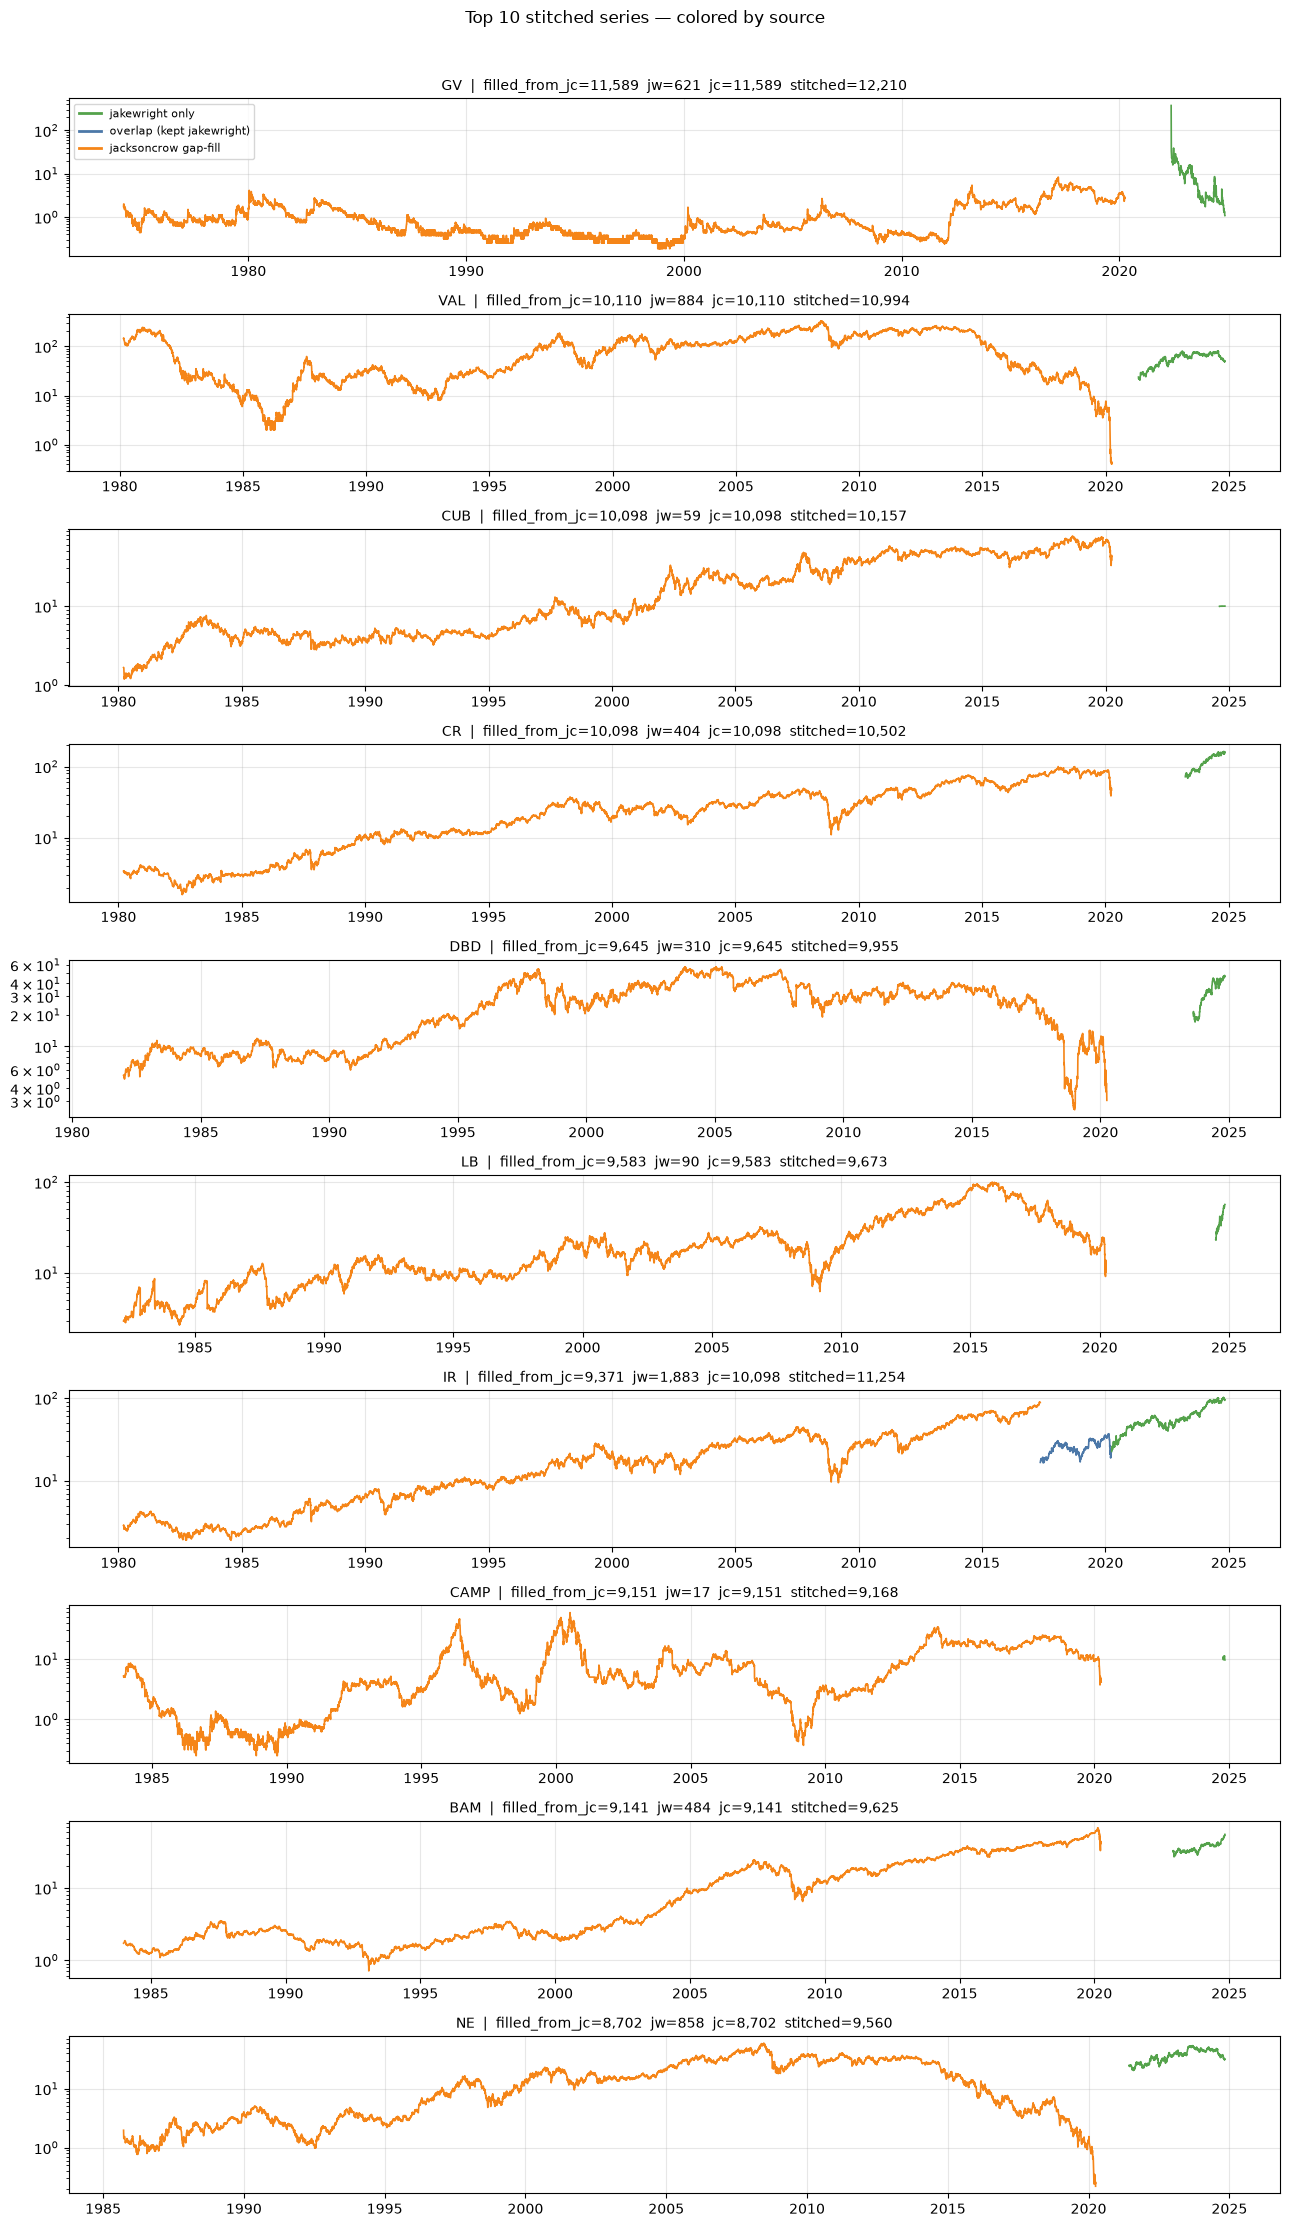

In [16]:
N = 10
top = fill_df.head(N)

def source_runs(dates, sources):
    """split into contiguous (start, end, source) segments for plotting."""
    runs = []
    if len(dates) == 0:
        return runs
    start = 0
    for i in range(1, len(dates)):
        if sources[i] != sources[i - 1]:
            runs.append((dates[start], dates[i - 1], sources[start]))
            start = i
    runs.append((dates[start], dates[-1], sources[start]))
    return runs


src_color = {
    "jakewright": colors["jakewright"],
    "jacksoncrow": colors["jacksoncrow"],
    "overlap_jw": colors["both"],
}

print(f"top {N} by filled_from_jc:")
display(top[["Ticker", "jw_bars", "jc_bars", "stitched_bars", "filled_from_jc", "first", "last"]])

fig, axes = plt.subplots(N, 1, figsize=(13, 2.2 * N), sharex=False)
if N == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, top.iterrows()):
    t = row["Ticker"]
    j = jw_grp[t]
    j = j[~j.index.duplicated(keep="last")]
    c = load_csv(JC / jc_kind.loc[t] / f"{t}.csv", usecols=["Date", "Close"], parse_dates=["Date"])
    c = c.set_index("Date")["Close"].sort_index()
    c = c[~c.index.duplicated(keep="last")]

    stitched = j.combine_first(c)
    in_j = stitched.index.isin(j.index)
    in_c = stitched.index.isin(c.index)
    src = pd.Series("jakewright", index=stitched.index)
    src.loc[~in_j & in_c] = "jacksoncrow"
    src.loc[in_j & in_c] = "overlap_jw"

    dates = stitched.index.to_numpy()
    vals = stitched.to_numpy()
    sources = src.to_numpy()
    for a, b, who in source_runs(dates, sources):
        mask = (stitched.index >= a) & (stitched.index <= b)
        ax.plot(stitched.index[mask], stitched.values[mask], color=src_color[who], lw=1.2)

    ax.set_yscale("log")
    ax.set_title(
        f"{t}  |  filled_from_jc={int(row['filled_from_jc']):,}  "
        f"jw={int(row['jw_bars']):,}  jc={int(row['jc_bars']):,}  stitched={int(row['stitched_bars']):,}",
        fontsize=10,
    )
    ax.grid(True, alpha=0.3)

# shared legend on last axis
for who, label in [
    ("jakewright", "jakewright only"),
    ("overlap_jw", "overlap (kept jakewright)"),
    ("jacksoncrow", "jacksoncrow gap-fill"),
]:
    axes[0].plot([], [], color=src_color[who], lw=2, label=label)
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle(f"Top {N} stitched series — colored by source", y=1.01)
plt.tight_layout()
plt.show()


## Live gap-fill (Stooq → yfinance fallback)

Same top-N series. Detect remaining interior/end gaps after Kaggle stitch, pull Close via **Stooq** first then **yfinance** if Stooq fails/rate-limits, merge fills, re-plot with source colors.

$GV: Data doesn't exist for startDate = 1000180800, endDate = 1000699200

1 Failed download:
['GV']: Data doesn't exist for startDate = 1000180800, endDate = 1000699200


  GV: skip window 2001-09-11→2001-09-16 (both sources failed for GV: yfinance empty for GV)


$GV: Data doesn't exist for startDate = 1585800000, endDate = 1652760000

1 Failed download:
['GV']: Data doesn't exist for startDate = 1585800000, endDate = 1652760000


  GV: skip window 2020-04-02→2022-05-16 (both sources failed for GV: yfinance empty for GV)
GV: gaps 2→3  +stooq=0  +yf=26


$VAL: Data doesn't exist for startDate = 1000180800, endDate = 1000699200

1 Failed download:
['VAL']: Data doesn't exist for startDate = 1000180800, endDate = 1000699200


...

$NE: Data doesn't exist for startDate = 1000180800, endDate = 1000699200

1 Failed download:
['NE']: Data doesn't exist for startDate = 1000180800, endDate = 1000699200


  NE: skip window 2001-09-11→2001-09-16 (both sources failed for NE: yfinance empty for NE)


$NE: Data doesn't exist for startDate = 1585800000, endDate = 1623211200

1 Failed download:
['NE']: Data doesn't exist for startDate = 1585800000, endDate = 1623211200


  NE: skip window 2020-04-02→2021-06-08 (both sources failed for NE: yfinance empty for NE)
NE: gaps 2→2  +stooq=0  +yf=450


,Ticker,gaps_before,gaps_after,filled_stooq,filled_yfinance,bars_after,first,last
0,GV,2,3,0,26,12236,1974-04-09,2026-08-21
1,VAL,2,2,0,450,11444,1980-02-28,2026-08-24
2,CUB,2,2,0,451,10608,1980-03-17,2026-08-24
3,CR,2,2,0,450,10952,1980-03-17,2026-08-24
4,DBD,2,2,0,450,10405,1981-12-31,2026-08-24
5,LB,2,2,0,450,10123,1982-04-01,2026-08-24
6,IR,1,1,0,450,11704,1980-03-17,2026-08-24
7,CAMP,2,2,0,450,9618,1983-12-13,2026-08-24
8,BAM,2,2,0,450,10075,1983-12-30,2026-08-24
9,NE,2,2,0,450,10010,1985-09-23,2026-08-24


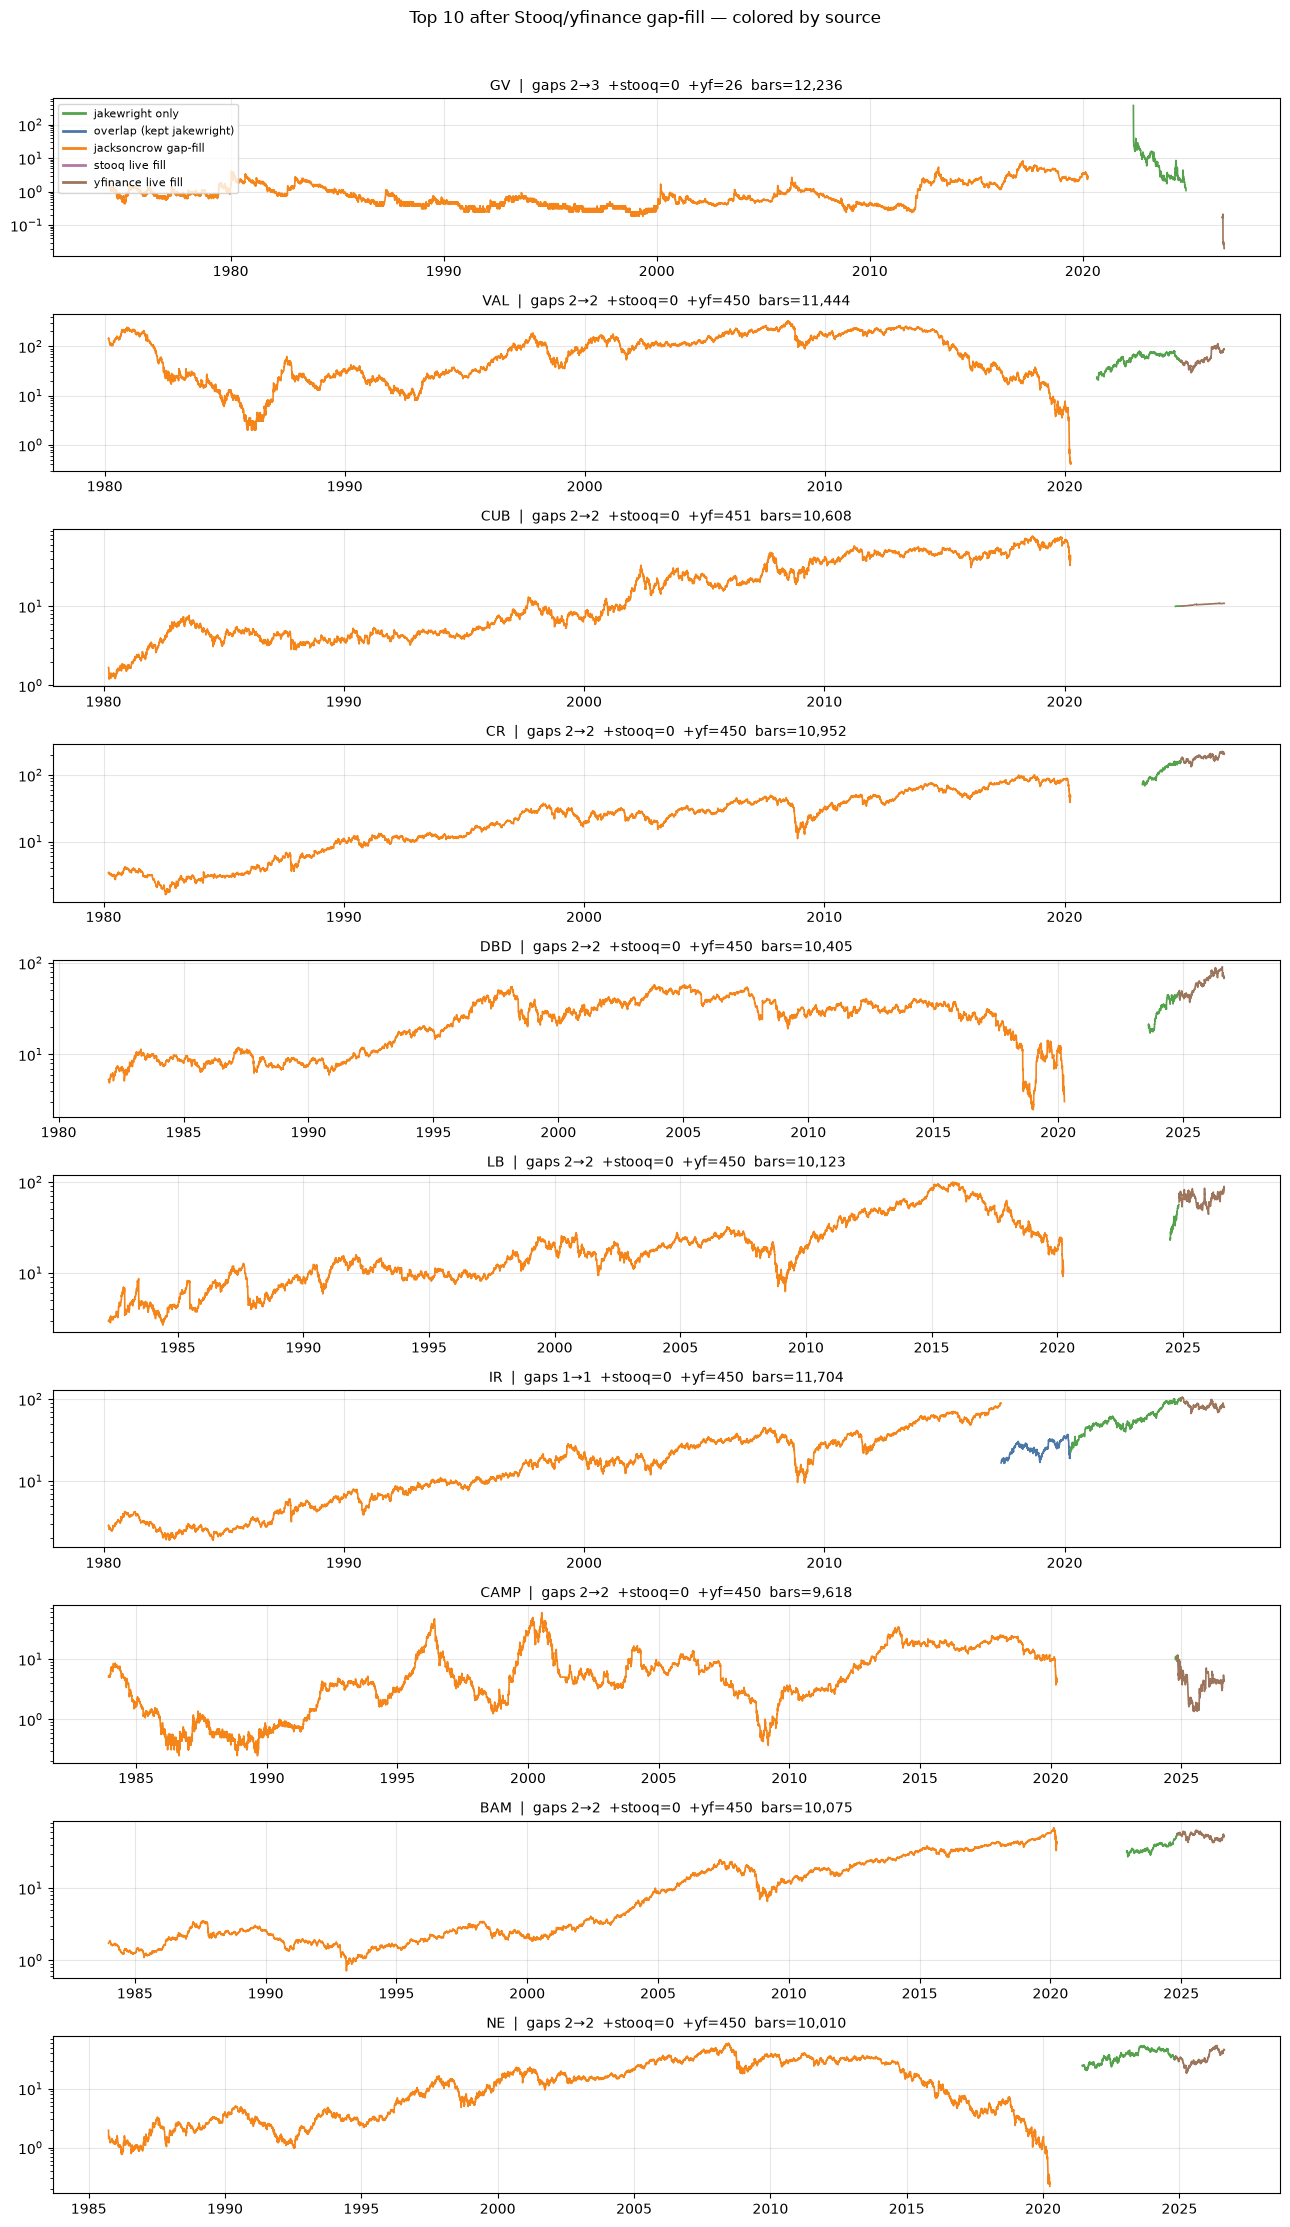

In [17]:
GAP_DAYS = 2  # calendar days between bars to treat as a remaining hole

def source_runs(dates, sources):
    runs = []
    if len(dates) == 0:
        return runs
    start = 0
    for i in range(1, len(dates)):
        if sources[i] != sources[i - 1]:
            runs.append((dates[start], dates[i - 1], sources[start]))
            start = i
    runs.append((dates[start], dates[-1], sources[start]))
    return runs


import time
from io import StringIO

import requests
import yfinance as yf
from dotenv import find_dotenv, load_dotenv
import os

load_dotenv(find_dotenv())
STOOQ_API_KEY = os.getenv("STOOQ_API_KEY", "").strip()


def fetch_stooq(ticker, start, end):
    """Daily Close from Stooq CSV. Needs STOOQ_API_KEY if site challenges anonymous pulls."""
    params = {
        "s": f"{ticker.lower()}.us",
        "i": "d",
        "d1": pd.Timestamp(start).strftime("%Y%m%d"),
        "d2": pd.Timestamp(end).strftime("%Y%m%d"),
    }
    if STOOQ_API_KEY:
        params["apikey"] = STOOQ_API_KEY
    r = requests.get(
        "https://stooq.com/q/d/l/",
        params=params,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=60,
    )
    text = r.text.strip()
    if not text or text.startswith("<") or "Exceeded" in text:
        raise RuntimeError(f"stooq blocked/empty for {ticker}: {text[:80]!r}")
    df = pd.read_csv(StringIO(text))
    df["Date"] = pd.to_datetime(df["Date"])
    s = df.set_index("Date")["Close"].sort_index().astype(float)
    s = s.loc[(s.index >= pd.Timestamp(start)) & (s.index <= pd.Timestamp(end))]
    if s.empty:
        raise RuntimeError(f"stooq empty range for {ticker}")
    return s


def fetch_yfinance(ticker, start, end):
    df = yf.download(
        ticker,
        start=pd.Timestamp(start).strftime("%Y-%m-%d"),
        end=(pd.Timestamp(end) + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        progress=False,
        auto_adjust=False,
        threads=False,
    )
    if df.empty:
        raise RuntimeError(f"yfinance empty for {ticker}")
    close = df["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close.index = pd.to_datetime(close.index).tz_localize(None)
    return close.astype(float).sort_index()


def fetch_close(ticker, start, end, prefer=("stooq", "yfinance")):
    """Try prefer-order; on failure/rate-limit rotate to the other."""
    last_err = None
    for src in prefer:
        try:
            fn = fetch_stooq if src == "stooq" else fetch_yfinance
            return fn(ticker, start, end), src
        except Exception as e:
            last_err = e
            time.sleep(0.4)
    raise RuntimeError(f"both sources failed for {ticker}: {last_err}")


def gap_windows(index, gap_days=GAP_DAYS, extend_to=None):
    """Open intervals (exclusive of endpoints) where consecutive bars are > gap_days apart."""
    idx = pd.DatetimeIndex(index).sort_values().unique()
    wins = []
    for left, right in zip(idx[:-1], idx[1:]):
        if (right - left).days > gap_days:
            wins.append((left + pd.Timedelta(days=1), right - pd.Timedelta(days=1)))
    if extend_to is not None and len(idx):
        end = pd.Timestamp(extend_to).normalize()
        if (end - idx[-1]).days > gap_days:
            wins.append((idx[-1] + pd.Timedelta(days=1), end))
    return wins


src_color = {
    "jakewright": colors["jakewright"],
    "jacksoncrow": colors["jacksoncrow"],
    "overlap_jw": colors["both"],
    "stooq": "#B279A2",
    "yfinance": "#9D755D",
}

today = pd.Timestamp.today().normalize()
live_rows = []
live_series = {}  # ticker -> (close, source_series)

for _, row in top.iterrows():
    t = row["Ticker"]
    j = jw_grp[t]
    j = j[~j.index.duplicated(keep="last")]
    c = load_csv(JC / jc_kind.loc[t] / f"{t}.csv", usecols=["Date", "Close"], parse_dates=["Date"])
    c = c.set_index("Date")["Close"].sort_index()
    c = c[~c.index.duplicated(keep="last")]

    stitched = j.combine_first(c)
    src = pd.Series("jakewright", index=stitched.index)
    in_j, in_c = stitched.index.isin(j.index), stitched.index.isin(c.index)
    src.loc[~in_j & in_c] = "jacksoncrow"
    src.loc[in_j & in_c] = "overlap_jw"

    gaps_before = len(gap_windows(stitched.index))
    filled_stooq = filled_yf = 0
    for a, b in gap_windows(stitched.index, extend_to=today):
        if a > b:
            continue
        try:
            pulled, who = fetch_close(t, a, b)
        except Exception as e:
            print(f"  {t}: skip window {a.date()}→{b.date()} ({e})")
            continue
        new = pulled[~pulled.index.isin(stitched.index)]
        new = new.loc[(new.index >= a) & (new.index <= b)]
        if new.empty:
            continue
        stitched = stitched.combine_first(new)
        src = src.combine_first(pd.Series(who, index=new.index))
        if who == "stooq":
            filled_stooq += len(new)
        else:
            filled_yf += len(new)
        time.sleep(0.35)

    live_series[t] = (stitched.sort_index(), src.reindex(stitched.index).sort_index())
    gaps_after = len(gap_windows(stitched.index, extend_to=today))
    live_rows.append(
        {
            "Ticker": t,
            "gaps_before": gaps_before,
            "gaps_after": gaps_after,
            "filled_stooq": filled_stooq,
            "filled_yfinance": filled_yf,
            "bars_after": len(stitched),
            "first": stitched.index.min(),
            "last": stitched.index.max(),
        }
    )
    print(f"{t}: gaps {gaps_before}→{gaps_after}  +stooq={filled_stooq}  +yf={filled_yf}")

live_df = pd.DataFrame(live_rows)
display(live_df)

fig, axes = plt.subplots(N, 1, figsize=(13, 2.2 * N), sharex=False)
if N == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, live_df.iterrows()):
    t = row["Ticker"]
    stitched, src = live_series[t]
    dates = stitched.index.to_numpy()
    sources = src.to_numpy()
    for a, b, who in source_runs(dates, sources):
        mask = (stitched.index >= a) & (stitched.index <= b)
        ax.plot(stitched.index[mask], stitched.values[mask], color=src_color.get(who, "#333"), lw=1.2)
    ax.set_yscale("log")
    ax.set_title(
        f"{t}  |  gaps {int(row['gaps_before'])}→{int(row['gaps_after'])}  "
        f"+stooq={int(row['filled_stooq'])}  +yf={int(row['filled_yfinance'])}  "
        f"bars={int(row['bars_after']):,}",
        fontsize=10,
    )
    ax.grid(True, alpha=0.3)

for who, label in [
    ("jakewright", "jakewright only"),
    ("overlap_jw", "overlap (kept jakewright)"),
    ("jacksoncrow", "jacksoncrow gap-fill"),
    ("stooq", "stooq live fill"),
    ("yfinance", "yfinance live fill"),
]:
    axes[0].plot([], [], color=src_color[who], lw=2, label=label)
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle(f"Top {N} after Stooq/yfinance gap-fill — colored by source", y=1.01)
plt.tight_layout()
plt.show()
